In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier, BaggingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
from imblearn.combine import SMOTETomek
import joblib


In [2]:
df = pd.read_csv('income_evaluation.csv')
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              32561 non-null  int64
 1    workclass       32561 non-null  str  
 2    fnlwgt          32561 non-null  int64
 3    education       32561 non-null  str  
 4    education-num   32561 non-null  int64
 5    marital-status  32561 non-null  str  
 6    occupation      32561 non-null  str  
 7    relationship    32561 non-null  str  
 8    race            32561 non-null  str  
 9    sex             32561 non-null  str  
 10   capital-gain    32561 non-null  int64
 11   capital-loss    32561 non-null  int64
 12   hours-per-week  32561 non-null  int64
 13   native-country  32561 non-null  str  
 14   income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.5 MB


In [4]:
df = df.rename(columns=lambda x: x.strip().replace(' ', '_').replace('-', '_').title())
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Age             32561 non-null  int64
 1   Workclass       32561 non-null  str  
 2   Fnlwgt          32561 non-null  int64
 3   Education       32561 non-null  str  
 4   Education_Num   32561 non-null  int64
 5   Marital_Status  32561 non-null  str  
 6   Occupation      32561 non-null  str  
 7   Relationship    32561 non-null  str  
 8   Race            32561 non-null  str  
 9   Sex             32561 non-null  str  
 10  Capital_Gain    32561 non-null  int64
 11  Capital_Loss    32561 non-null  int64
 12  Hours_Per_Week  32561 non-null  int64
 13  Native_Country  32561 non-null  str  
 14  Income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.5 MB


In [5]:
# Removing leading & trailing spaces from data
df = df.apply(lambda x: x.str.strip().str.title() if x.dtype == "str" else x)

In [6]:
df.isnull().sum()

Age               0
Workclass         0
Fnlwgt            0
Education         0
Education_Num     0
Marital_Status    0
Occupation        0
Relationship      0
Race              0
Sex               0
Capital_Gain      0
Capital_Loss      0
Hours_Per_Week    0
Native_Country    0
Income            0
dtype: int64

In [7]:
# Removed entries with '?'
df = df[~(df == '?').any(axis=1)]

# removing irrelavant columns
df.drop(['Fnlwgt','Education_Num','Relationship'], axis=1, inplace=True)

In [8]:
df.info()

<class 'pandas.DataFrame'>
Index: 30162 entries, 0 to 32560
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Age             30162 non-null  int64
 1   Workclass       30162 non-null  str  
 2   Education       30162 non-null  str  
 3   Marital_Status  30162 non-null  str  
 4   Occupation      30162 non-null  str  
 5   Race            30162 non-null  str  
 6   Sex             30162 non-null  str  
 7   Capital_Gain    30162 non-null  int64
 8   Capital_Loss    30162 non-null  int64
 9   Hours_Per_Week  30162 non-null  int64
 10  Native_Country  30162 non-null  str  
 11  Income          30162 non-null  str  
dtypes: int64(4), str(8)
memory usage: 5.1 MB


In [9]:
df.duplicated().sum()

np.int64(4096)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,26066.0,39.385138,13.156659,17.0,29.0,38.0,48.0,90.0
Capital_Gain,26066.0,1254.472109,7926.611311,0.0,0.0,0.0,0.0,99999.0
Capital_Loss,26066.0,101.595910,431.935662,0.0,0.0,0.0,0.0,4356.0
Hours_Per_Week,26066.0,41.262641,12.478896,1.0,40.0,40.0,45.0,99.0


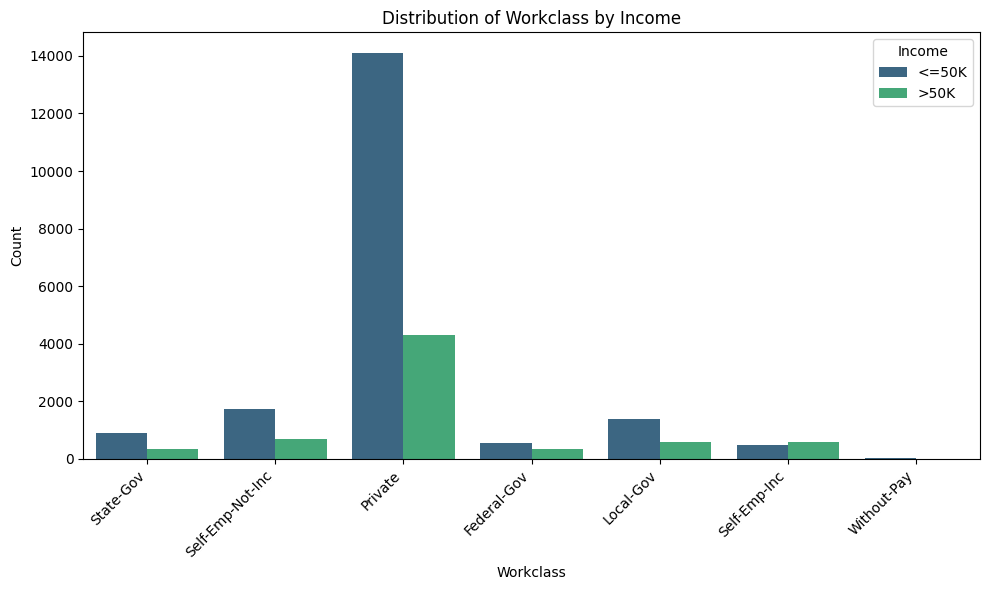

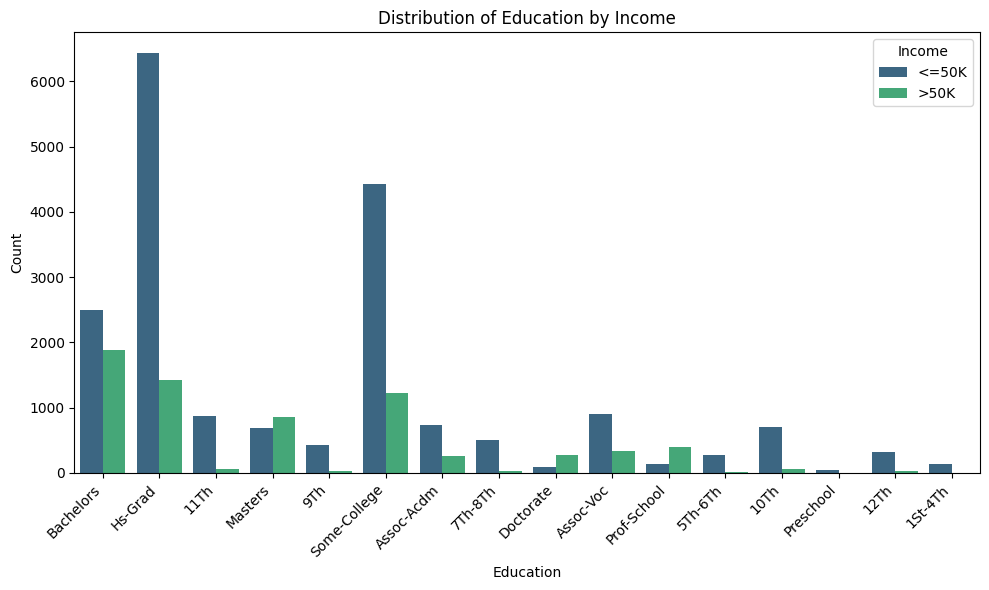

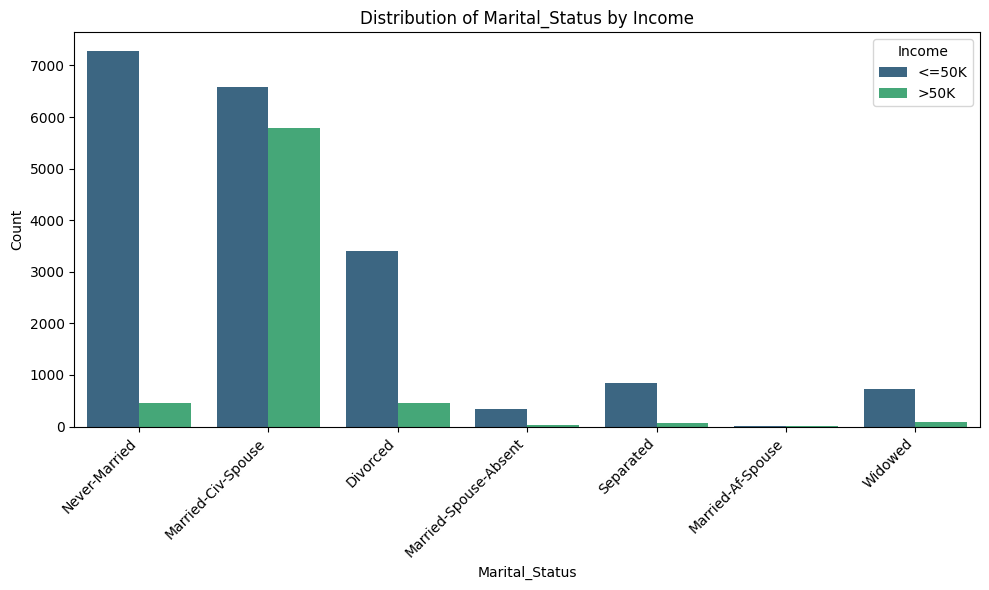

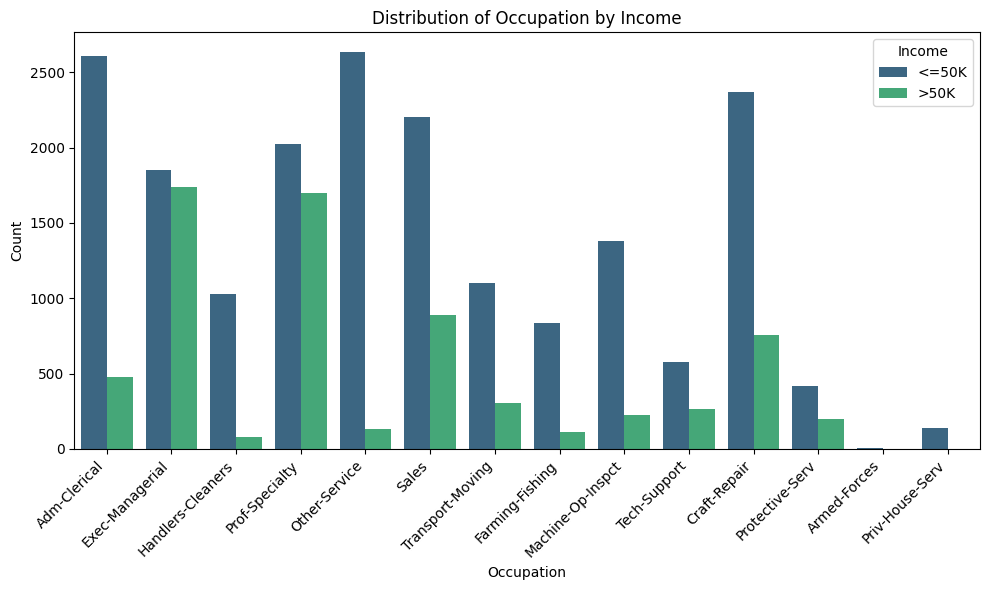

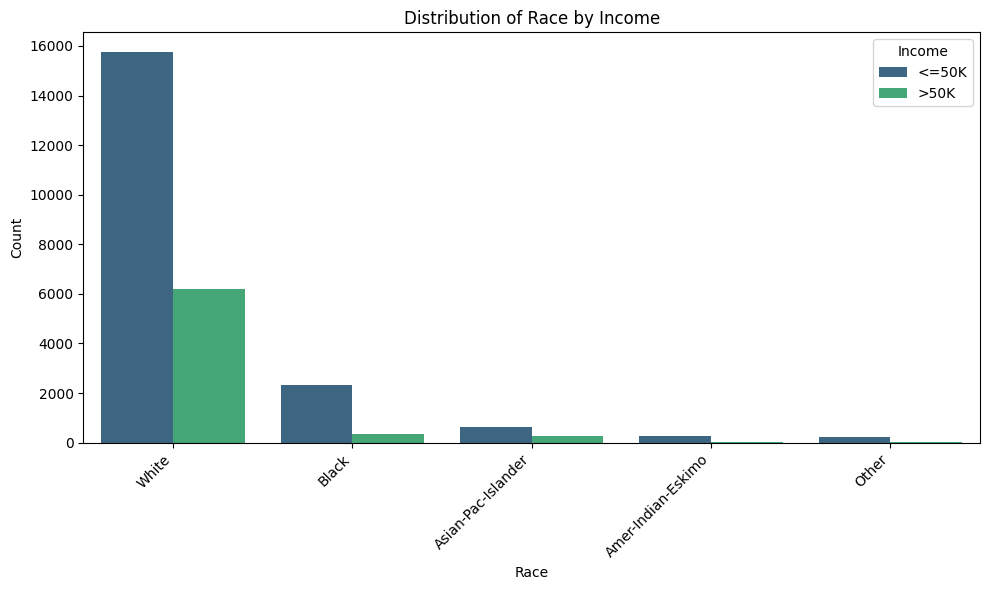

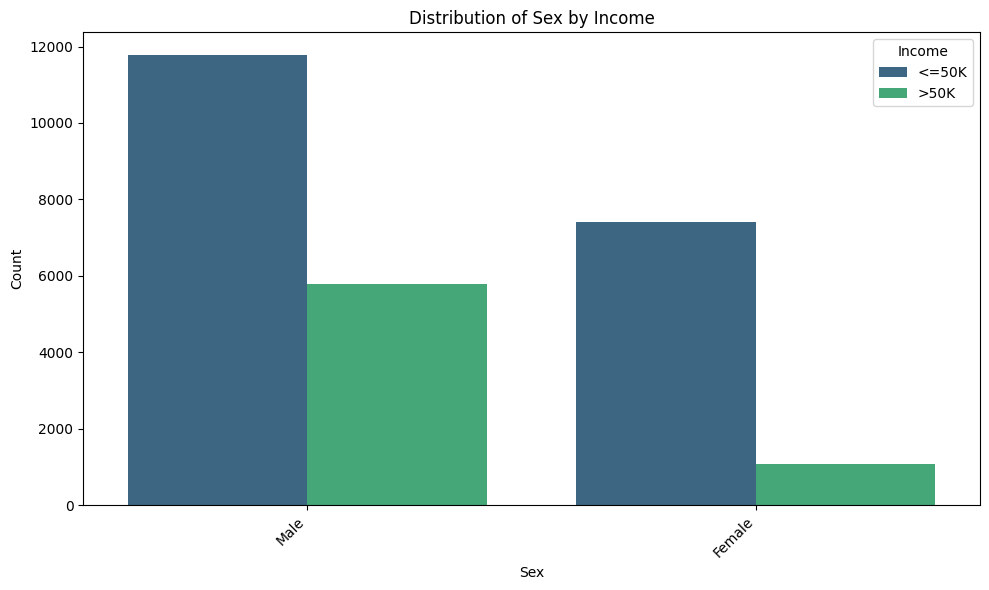

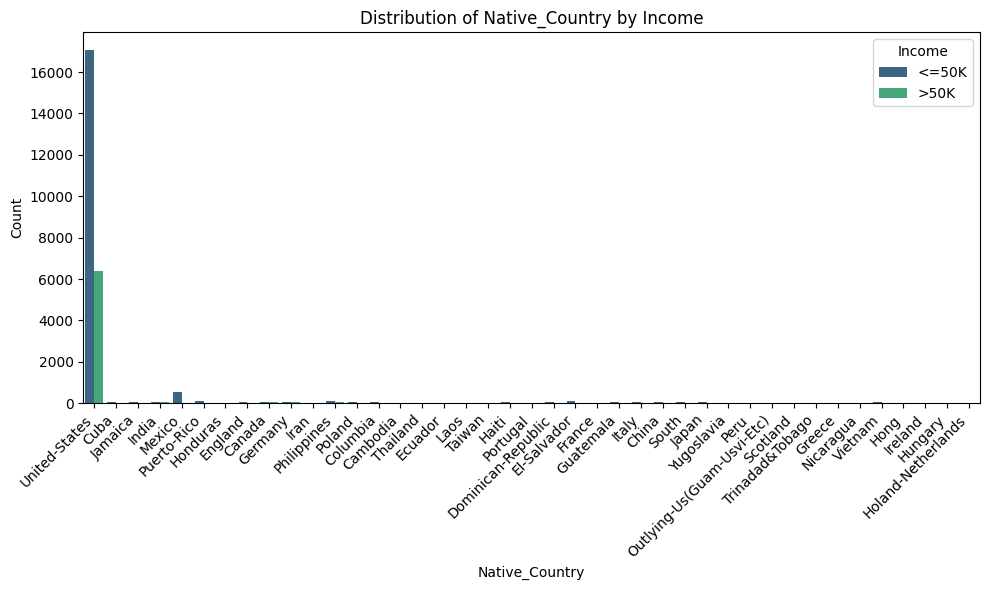

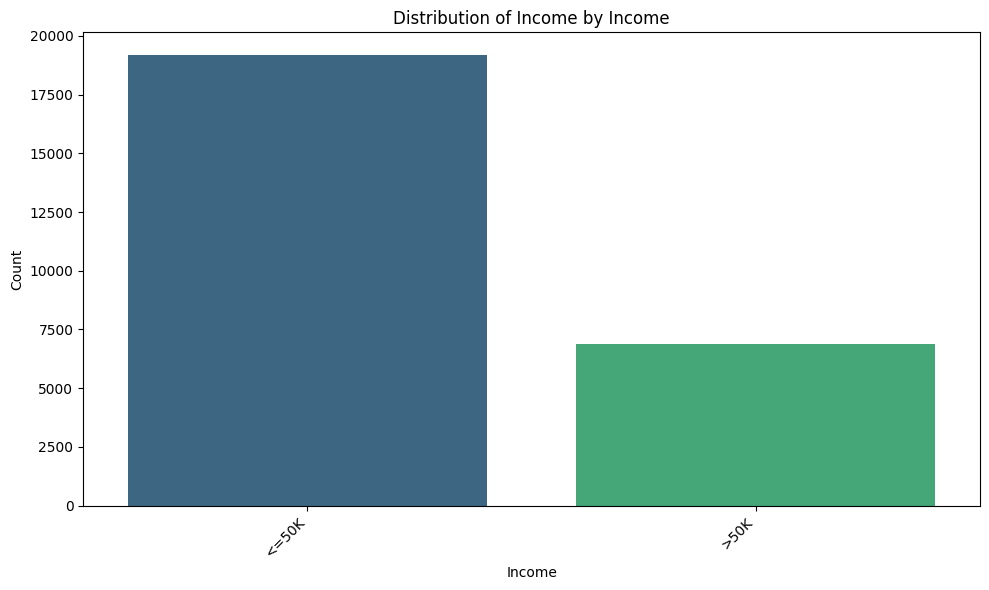

In [12]:
# Visualize the distribution of categorical variables
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col, hue='Income', palette='viridis')
    plt.title(f'Distribution of {col} by Income')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

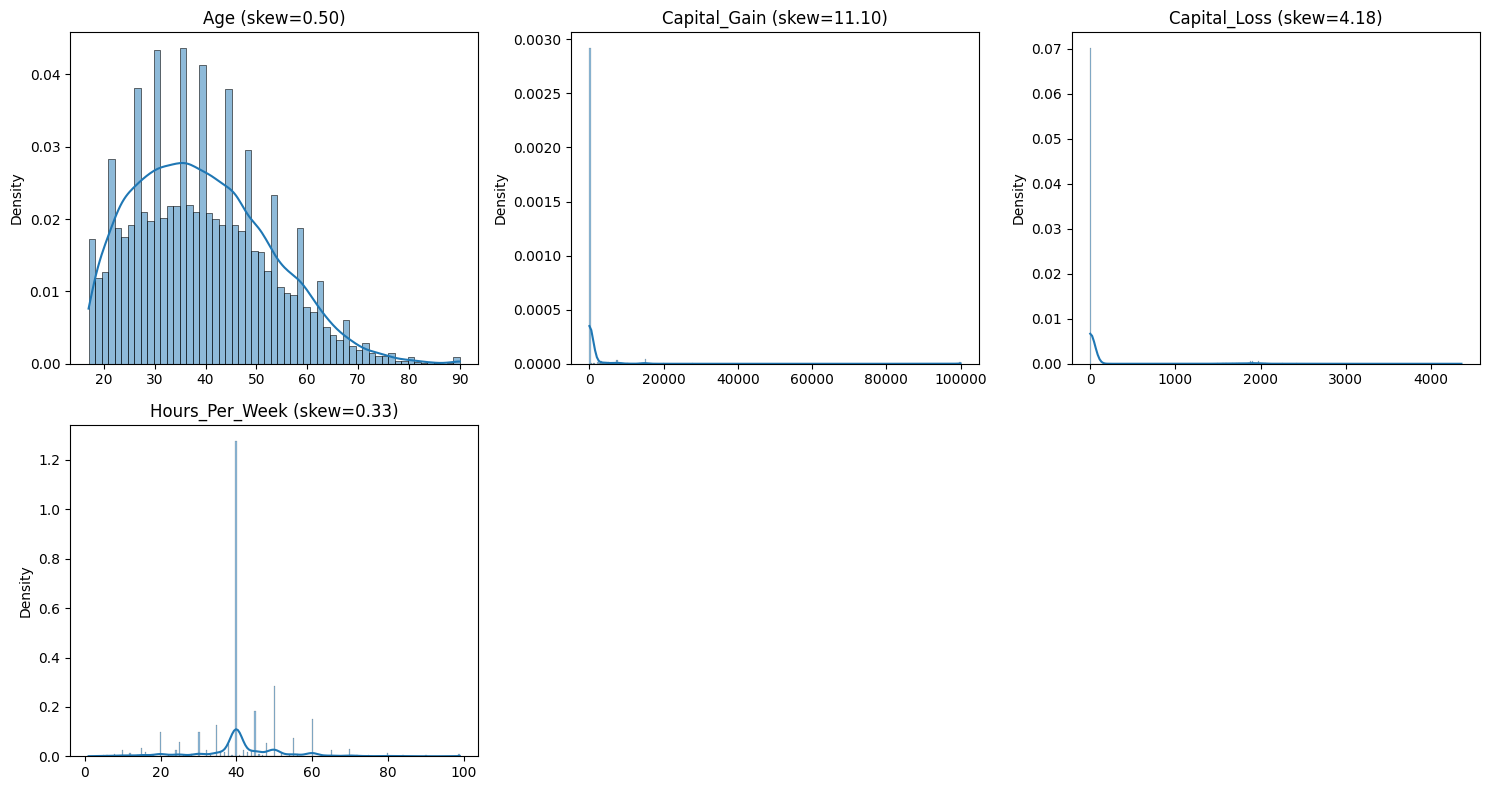

In [13]:
# Visualize the distribution of numerical variables
numerical_cols = df.select_dtypes(include=np.number).columns
n = len(numerical_cols)
cols_per_row = 3
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row * 5, rows * 4))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], stat='density', color='C0')
    axes[i].set_title(f'{col} (skew={df[col].skew():.2f})')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density')

# remove any unused axes
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

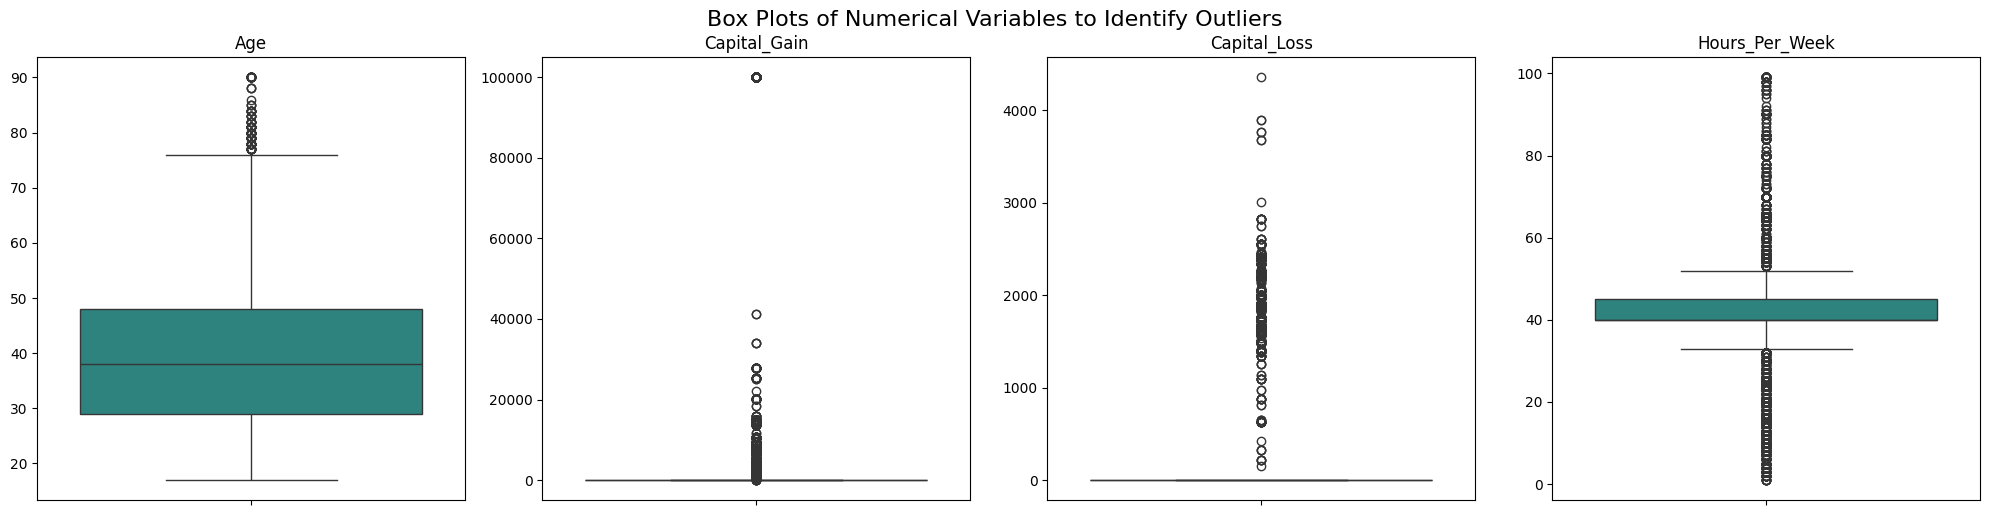

In [14]:
# Visualize the box plots for numerical variables
num_plots = len(numerical_cols)
num_rows = (num_plots + 3) // 4  # Adjust for 4 plots per row
num_cols = 4

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], palette='viridis')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('') # Remove y-label for cleaner look
    axes[i].tick_params(axis='y', labelsize=10)

# Hide any unused subplots
for i in range(num_plots, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.suptitle('Box Plots of Numerical Variables to Identify Outliers', y=1.02, fontsize=16)
plt.show()

In [15]:
# convert categorical to numeric
label_encoders = {}

for col in categorical_cols:
    label_encoders[col] = LabelEncoder()
    df[col] = label_encoders[col].fit_transform(df[col])
    print({label: index for index, label in enumerate(label_encoders[col].classes_)})

{'Federal-Gov': 0, 'Local-Gov': 1, 'Private': 2, 'Self-Emp-Inc': 3, 'Self-Emp-Not-Inc': 4, 'State-Gov': 5, 'Without-Pay': 6}
{'10Th': 0, '11Th': 1, '12Th': 2, '1St-4Th': 3, '5Th-6Th': 4, '7Th-8Th': 5, '9Th': 6, 'Assoc-Acdm': 7, 'Assoc-Voc': 8, 'Bachelors': 9, 'Doctorate': 10, 'Hs-Grad': 11, 'Masters': 12, 'Preschool': 13, 'Prof-School': 14, 'Some-College': 15}
{'Divorced': 0, 'Married-Af-Spouse': 1, 'Married-Civ-Spouse': 2, 'Married-Spouse-Absent': 3, 'Never-Married': 4, 'Separated': 5, 'Widowed': 6}
{'Adm-Clerical': 0, 'Armed-Forces': 1, 'Craft-Repair': 2, 'Exec-Managerial': 3, 'Farming-Fishing': 4, 'Handlers-Cleaners': 5, 'Machine-Op-Inspct': 6, 'Other-Service': 7, 'Priv-House-Serv': 8, 'Prof-Specialty': 9, 'Protective-Serv': 10, 'Sales': 11, 'Tech-Support': 12, 'Transport-Moving': 13}
{'Amer-Indian-Eskimo': 0, 'Asian-Pac-Islander': 1, 'Black': 2, 'Other': 3, 'White': 4}
{'Female': 0, 'Male': 1}
{'Cambodia': 0, 'Canada': 1, 'China': 2, 'Columbia': 3, 'Cuba': 4, 'Dominican-Republic': 

In [16]:
df.columns

Index(['Age', 'Workclass', 'Education', 'Marital_Status', 'Occupation', 'Race',
       'Sex', 'Capital_Gain', 'Capital_Loss', 'Hours_Per_Week',
       'Native_Country', 'Income'],
      dtype='str')

In [17]:
df.info()

<class 'pandas.DataFrame'>
Index: 26066 entries, 0 to 32560
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Age             26066 non-null  int64
 1   Workclass       26066 non-null  int64
 2   Education       26066 non-null  int64
 3   Marital_Status  26066 non-null  int64
 4   Occupation      26066 non-null  int64
 5   Race            26066 non-null  int64
 6   Sex             26066 non-null  int64
 7   Capital_Gain    26066 non-null  int64
 8   Capital_Loss    26066 non-null  int64
 9   Hours_Per_Week  26066 non-null  int64
 10  Native_Country  26066 non-null  int64
 11  Income          26066 non-null  int64
dtypes: int64(12)
memory usage: 2.6 MB


In [18]:
df.head()

,Age,Workclass,Education,Marital_Status,Occupation,Race,Sex,Capital_Gain,Capital_Loss,Hours_Per_Week,Native_Country,Income
0,39,5,9,4,0,4,1,2174,0,40,38,0
1,50,4,9,2,3,4,1,0,0,13,38,0
2,38,2,11,0,5,4,1,0,0,40,38,0
3,53,2,1,2,5,2,1,0,0,40,38,0
4,28,2,9,2,9,2,0,0,0,40,4,0


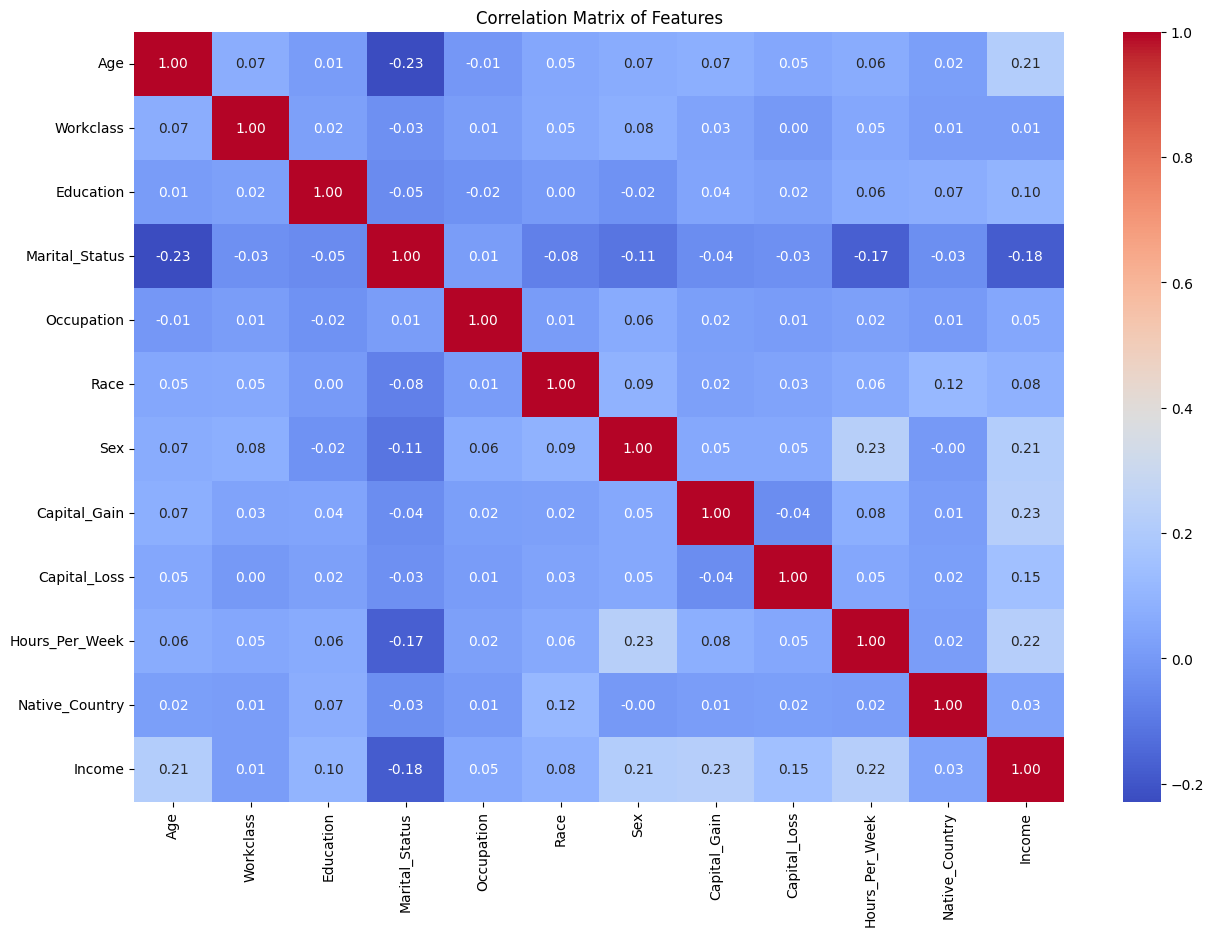

In [19]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

In [20]:
df.skew()

Age                0.499437
Workclass          1.023408
Education         -0.891260
Marital_Status     0.064282
Occupation         0.067130
Race              -2.311290
Sex               -0.743475
Capital_Gain      11.098345
Capital_Loss       4.177246
Hours_Per_Week     0.332217
Native_Country    -3.851107
Income             1.071835
dtype: float64

#### Observations : 
#### i. Few entries for >50K income than <=50k income. Due to class imbalance, efficiency may reduce.
#### ii. Removed entries with "?" as replacing them with mean or mode doesn't make any sense.

#### Function to evaluate model performance

In [21]:
training_accuracy_scores = []
testing_accuracy_scores = []
overfitting_status = []
overfitting_threshold = 0.05

def ClearMetrics():
    training_accuracy_scores.clear()
    testing_accuracy_scores.clear()
    overfitting_status.clear()

def EvaluateModel(p_model, p_x_train, p_y_train, p_x_test, p_y_test):
    p_model.fit(p_x_train, p_y_train)
    
    y_train_pred = p_model.predict(p_x_train)
    accuracy_score_train = accuracy_score(p_y_train, y_train_pred)
    training_accuracy_scores.append(np.round(accuracy_score_train, 4))
    
    y_test_pred = p_model.predict(p_x_test)
    accuracy_score_test = accuracy_score(p_y_test, y_test_pred)
    testing_accuracy_scores.append(np.round(accuracy_score_test, 4))

    overfitting_status.append("Y" if abs(accuracy_score_train - accuracy_score_test) > overfitting_threshold else "N")

In [22]:
def EndToEndEvaluation(p_models, p_x_train, p_y_train, p_x_test, p_y_test):
    ClearMetrics()
    for l_model in p_models:
        EvaluateModel(l_model, p_x_train, p_y_train, p_x_test, p_y_test)

    results_df = pd.DataFrame({
        'Model': [model.__class__.__name__ for model in p_models],
        'Train Accuracy': training_accuracy_scores,
        'Test Accuracy': testing_accuracy_scores,
        'Overfitting (Y/N)': overfitting_status
    })

    results_df = results_df.sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)
    return results_df

In [23]:
models = [
    LogisticRegression(),
    BernoulliNB(),
    DecisionTreeClassifier(random_state=42),
    RandomForestClassifier(random_state=42),
    SVC(),
    KNeighborsClassifier(),
    GradientBoostingClassifier(random_state=42),
    AdaBoostClassifier(random_state=42),
    XGBClassifier(random_state=42),
    VotingClassifier(estimators=[
        ('lr', LogisticRegression()),
        ('svc', SVC()),
        ('knn', KNeighborsClassifier()),
        ('rf', DecisionTreeClassifier(random_state=42))
    ])
]

#### Evaluate without EDA

In [24]:
df_without_eda = df.copy()

x = df_without_eda.drop(columns=['Income'])
y = df_without_eda['Income']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Model evaluation without EDA :")
EndToEndEvaluation(models, x_train, y_train, x_test, y_test)

Model evaluation without EDA :


,Model,Train Accuracy,Test Accuracy,Overfitting (Y/N)
0,XGBClassifier,0.8921,0.8631,N
1,GradientBoostingClassifier,0.8563,0.8540,N
2,AdaBoostClassifier,0.8311,0.8337,N
3,VotingClassifier,0.8212,0.8186,N
4,RandomForestClassifier,0.9812,0.8180,Y
5,KNeighborsClassifier,0.8748,0.8132,Y
6,SVC,0.7868,0.7906,N
7,DecisionTreeClassifier,0.9812,0.7840,Y
8,LogisticRegression,0.7844,0.7831,N
9,BernoulliNB,0.7718,0.7722,N


#### Resolve class imbalance issue & check efficiency 

In [26]:
smk = SMOTETomek(random_state=42)
x_res,y_res=smk.fit_resample(x,y)

x_train, x_test, y_train, y_test = train_test_split(x_res, y_res, test_size=0.2, random_state=42)

print("Model evaluation post resolving class imbalance (without EDA) :")
EndToEndEvaluation(models, x_train, y_train, x_test, y_test)

Model evaluation post resolving class imbalance (without EDA) :


,Model,Train Accuracy,Test Accuracy,Overfitting (Y/N)
0,RandomForestClassifier,0.9815,0.8793,Y
1,XGBClassifier,0.9020,0.8777,N
2,GradientBoostingClassifier,0.8584,0.8481,N
3,DecisionTreeClassifier,0.9815,0.8397,Y
4,KNeighborsClassifier,0.8940,0.8397,Y
5,AdaBoostClassifier,0.8332,0.8264,N
6,VotingClassifier,0.8213,0.7735,N
7,LogisticRegression,0.6753,0.6685,N
8,BernoulliNB,0.6509,0.6466,N
9,SVC,0.6387,0.6367,N


In [ ]:
print(x.shape)
print(x_res.shape)
print(y.shape)
print(y_res.shape)

(26066, 11)
(37394, 11)
(26066,)
(37394,)


In [29]:
y.value_counts()

Income
0    19189
1     6877
Name: count, dtype: int64

In [30]:
y_res.value_counts()

Income
0    18697
1    18697
Name: count, dtype: int64

#### Perform EDA

In [41]:
df_eda = df.copy()

In [42]:
df_eda.skew()

Age                0.499437
Workclass          1.023408
Education         -0.891260
Marital_Status     0.064282
Occupation         0.067130
Race              -2.311290
Sex               -0.743475
Capital_Gain      11.098345
Capital_Loss       4.177246
Hours_Per_Week     0.332217
Native_Country    -3.851107
Income             1.071835
dtype: float64

In [43]:
skewed_cols = [col for col in df_eda.columns if ((df_eda[col].skew() > 0.5 or df_eda[col].skew() < -0.5) and col not in categorical_cols)]
skewed_cols

['Capital_Gain', 'Capital_Loss']

In [44]:
# Applying log transformation to reduce skewness

for col in skewed_cols:
    df_eda[col] = np.log1p(df_eda[col])

In [45]:
df_eda.skew()

Age               0.499437
Workclass         1.023408
Education        -0.891260
Marital_Status    0.064282
Occupation        0.067130
Race             -2.311290
Sex              -0.743475
Capital_Gain      2.800232
Capital_Loss      3.936806
Hours_Per_Week    0.332217
Native_Country   -3.851107
Income            1.071835
dtype: float64

In [46]:
numerical_cols

Index(['Age', 'Capital_Gain', 'Capital_Loss', 'Hours_Per_Week'], dtype='str')

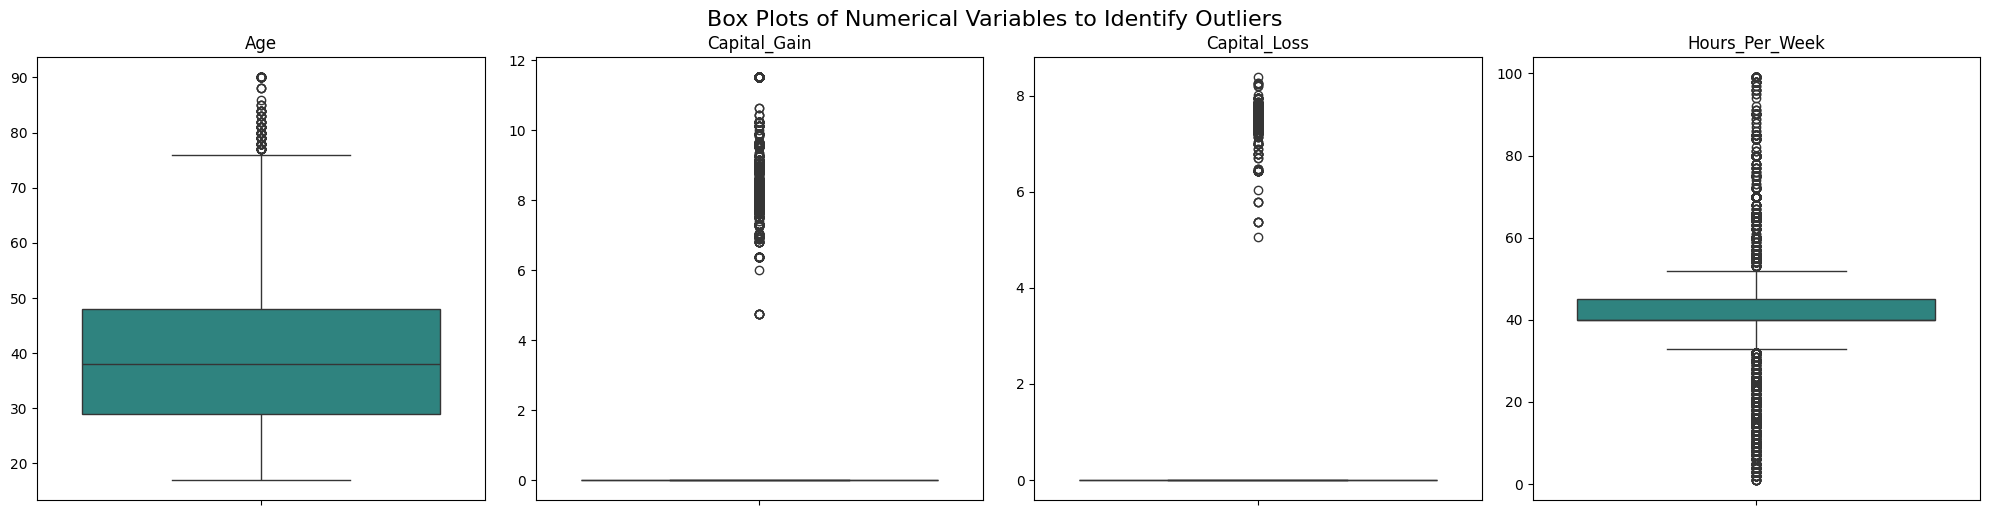

In [47]:
# outlier detection

predictors = [col for col in df_eda.columns if col in numerical_cols]
num_plots = len(predictors)
num_rows = (num_plots + 3) // 4  # Adjust for 4 plots per row
num_cols = 4

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(predictors):
    sns.boxplot(y=df_eda[col], ax=axes[i], palette='viridis')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('') # Remove y-label for cleaner look
    axes[i].tick_params(axis='y', labelsize=10)

# Hide any unused subplots
for i in range(num_plots, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.suptitle('Box Plots of Numerical Variables to Identify Outliers', y=1.02, fontsize=16)
plt.show()

In [48]:
def Get_iqr_bounds(p_df, p_column):
    Q1 = p_df[p_column].quantile(0.25)
    Q3 = p_df[p_column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    return lower_bound, upper_bound
    
def handle_outliers(p_df, p_column):
    lower_bound, upper_bound = Get_iqr_bounds(p_df, p_column)
    print("handle_outliers :: " + p_column + " : lower_bound : ", lower_bound, ", upper_bound : ", upper_bound)
    #capping values outside the bounds
    p_df[p_column] = np.where((p_df[p_column] < lower_bound), lower_bound, p_df[p_column])
    p_df[p_column] = np.where((p_df[p_column] > upper_bound), upper_bound, p_df[p_column])

def Get_outliers_percentage(p_df, p_column):
    lower_bound, upper_bound = Get_iqr_bounds(p_df, p_column)
    total_count = len(p_df)
    outliers_count = p_df[(p_df[p_column] < lower_bound) | (p_df[p_column] > upper_bound)].shape[0]
    outliers_percentage = (outliers_count / total_count) * 100
    print(f"Get_outliers_percentage :: {p_column} : Outliers Percentage: {outliers_percentage:.2f}% , outliers_count : {outliers_count} , total_count : {total_count}")
    return outliers_percentage

#Handling outliers by capping them using IQR method if outliers percentage is less than or equal to 5%
for col in predictors:
    if Get_outliers_percentage(df_eda, col) <= 5:
        handle_outliers(df_eda, col)

Get_outliers_percentage :: Age : Outliers Percentage: 0.53% , outliers_count : 138 , total_count : 26066
handle_outliers :: Age : lower_bound :  0.5 , upper_bound :  76.5
Get_outliers_percentage :: Capital_Gain : Outliers Percentage: 9.68% , outliers_count : 2524 , total_count : 26066
Get_outliers_percentage :: Capital_Loss : Outliers Percentage: 5.44% , outliers_count : 1418 , total_count : 26066
Get_outliers_percentage :: Hours_Per_Week : Outliers Percentage: 28.24% , outliers_count : 7360 , total_count : 26066


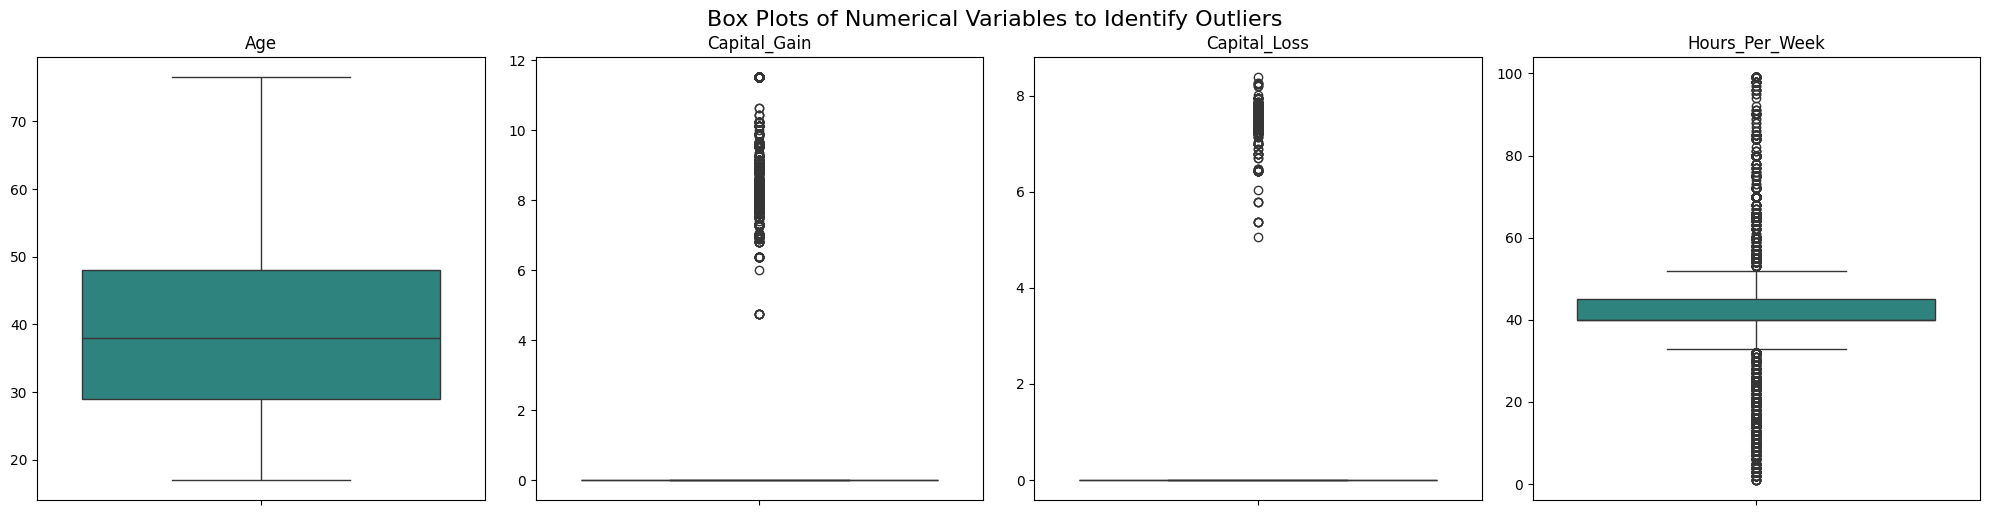

In [49]:
# distribution post outlier detection

num_plots = len(predictors)
num_rows = (num_plots + 3) // 4  # Adjust for 4 plots per row
num_cols = 4

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(predictors):
    sns.boxplot(y=df_eda[col], ax=axes[i], palette='viridis')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('') # Remove y-label for cleaner look
    axes[i].tick_params(axis='y', labelsize=10)

# Hide any unused subplots
for i in range(num_plots, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.suptitle('Box Plots of Numerical Variables to Identify Outliers', y=1.02, fontsize=16)
plt.show()

In [50]:
df_eda.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,26066.0,39.353334,13.054575,17.0,29.0,38.0,48.0,76.500000
Workclass,26066.0,2.224085,1.008579,0.0,2.0,2.0,2.0,6.000000
Education,26066.0,10.218215,3.882026,0.0,9.0,11.0,12.0,15.000000
Marital_Status,26066.0,2.541433,1.521680,0.0,2.0,2.0,4.0,6.000000
Occupation,26066.0,6.085322,4.022316,0.0,3.0,6.0,9.0,13.000000
Race,26066.0,3.638648,0.879623,0.0,4.0,4.0,4.0,4.000000
Sex,26066.0,0.674212,0.468678,0.0,0.0,1.0,1.0,1.000000
Capital_Gain,26066.0,0.855491,2.631261,0.0,0.0,0.0,0.0,11.512925
Capital_Loss,26066.0,0.408438,1.703914,0.0,0.0,0.0,0.0,8.379539
Hours_Per_Week,26066.0,41.262641,12.478896,1.0,40.0,40.0,45.0,99.000000


In [51]:
x = df_eda.drop(columns=['Income'])
y = df_eda['Income']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Model evaluation with EDA & without scaling :")
EndToEndEvaluation(models, x_train, y_train, x_test, y_test)

Model evaluation with EDA & without scaling :


,Model,Train Accuracy,Test Accuracy,Overfitting (Y/N)
0,XGBClassifier,0.8919,0.8608,N
1,GradientBoostingClassifier,0.8565,0.8554,N
2,AdaBoostClassifier,0.8311,0.8337,N
3,RandomForestClassifier,0.9812,0.8203,Y
4,VotingClassifier,0.8093,0.7932,N
5,DecisionTreeClassifier,0.9812,0.7835,Y
6,SVC,0.7743,0.7748,N
7,KNeighborsClassifier,0.8468,0.7729,Y
8,BernoulliNB,0.7718,0.7722,N
9,LogisticRegression,0.7699,0.7668,N


In [52]:
#Feature scaling

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Model evaluation with EDA & scaling :")
EndToEndEvaluation(models, x_train_scaled, y_train, x_test_scaled, y_test)

Model evaluation with EDA & scaling :


,Model,Train Accuracy,Test Accuracy,Overfitting (Y/N)
0,XGBClassifier,0.8919,0.8608,N
1,GradientBoostingClassifier,0.8565,0.8554,N
2,AdaBoostClassifier,0.8311,0.8337,N
3,RandomForestClassifier,0.9812,0.8195,Y
4,SVC,0.8199,0.8124,N
5,VotingClassifier,0.8461,0.8051,N
6,KNeighborsClassifier,0.8585,0.7883,Y
7,DecisionTreeClassifier,0.9812,0.7837,Y
8,LogisticRegression,0.7758,0.7762,N
9,BernoulliNB,0.7701,0.7712,N


In [53]:
# Resolving class imbalance using SMOTETomek
x_res,y_res=smk.fit_resample(x,y)
x_train, x_test, y_train, y_test = train_test_split(x_res, y_res, test_size=0.2, random_state=42)

scaler1 = StandardScaler()

x_train_scaled = scaler1.fit_transform(x_train)
x_test_scaled = scaler1.transform(x_test)

print("Model evaluation with EDA & scaling after resolving class imbalance :")
EndToEndEvaluation(models, x_train_scaled, y_train, x_test_scaled, y_test)

Model evaluation with EDA & scaling after resolving class imbalance :


,Model,Train Accuracy,Test Accuracy,Overfitting (Y/N)
0,XGBClassifier,0.9049,0.8767,N
1,RandomForestClassifier,0.9856,0.8753,Y
2,GradientBoostingClassifier,0.8571,0.8522,N
3,VotingClassifier,0.9092,0.8458,Y
4,KNeighborsClassifier,0.8824,0.8360,N
5,DecisionTreeClassifier,0.9856,0.8309,Y
6,AdaBoostClassifier,0.8326,0.8291,N
7,SVC,0.8285,0.8240,N
8,BernoulliNB,0.7264,0.7293,N
9,LogisticRegression,0.7084,0.7176,N


#### Observation : XGBClassifier is best performing model with EDA & scaling. 

#### Without resolving calss imbalance =>  Train Accuracy : 0.8919 , Test Accuracy : 0.8608 , Overfitting : N
#### After resolving calss imbalance =>    Train Accuracy : 0.9049 , Test Accuracy : 0.8767 , Overfitting : N

#### As accuracy increased post resolving class imbalace issue, selecting XGBClassifier with EDA & resolved class imbalace issue & Scaling.
#### Now we are going to try hyperparameter tuning on XGBClassifier algo to get best parameters.

In [54]:
best_performing_model = models[8] # XGBClassifier

l_param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.1, 0.5],
    'max_depth': [3, 5],
    'min_child_weight': [1, 3],
    'gamma': [0, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0.1, 1.0],
    'reg_lambda': [1.0, 2.0]
}

x = df_eda.drop(columns=['Income'])
y = df_eda['Income']
x_res,y_res=smk.fit_resample(x,y)
x_train, x_test, y_train, y_test = train_test_split(x_res, y_res, test_size=0.2, random_state=42)
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
grid_search = GridSearchCV(estimator=best_performing_model, param_grid=l_param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(x_train_scaled, y_train)

best_model_XGB = grid_search.best_estimator_
print("Best Hyperparameters for XGBClassifier model:", grid_search.best_params_)

Fitting 5 folds for each of 512 candidates, totalling 2560 fits
Best Hyperparameters for XGBClassifier model: {'colsample_bytree': 1.0, 'gamma': 0.1, 'learning_rate': 0.5, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 100, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 1.0}


In [55]:
l_models = [best_model_XGB]
print("Best Model evaluation with EDA & scaling (GridSearchCV) :")
EndToEndEvaluation(l_models, x_train_scaled, y_train, x_test_scaled, y_test)

Best Model evaluation with EDA & scaling (GridSearchCV) :


,Model,Train Accuracy,Test Accuracy,Overfitting (Y/N)
0,XGBClassifier,0.9044,0.8811,N


#### Best Hyperparameters for XGBClassifier model: {'colsample_bytree': 1.0, 'gamma': 0.1, 'learning_rate': 0.5, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 100, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 1.0}

#### Pre hyperparameter tuning :	Train Accuracy : 0.9049 , Test Accuracy : 0.8767 , Overfitting : N
#### Post hyperparameter tuning :	Train Accuracy : 0.9044 , Test Accuracy : 0.8811 , Overfitting : N

#### Conclusion : Selecting XGBClassifier model with best parameters

In [56]:
#dump the best performing model which is XGBClassifier model with hyperparameter tuning using GridSearchCV and scaler object for future use in inference
joblib.dump(best_model_XGB, 'XGBClassifier_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [57]:
df_eda.info()

<class 'pandas.DataFrame'>
Index: 26066 entries, 0 to 32560
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             26066 non-null  float64
 1   Workclass       26066 non-null  int64  
 2   Education       26066 non-null  int64  
 3   Marital_Status  26066 non-null  int64  
 4   Occupation      26066 non-null  int64  
 5   Race            26066 non-null  int64  
 6   Sex             26066 non-null  int64  
 7   Capital_Gain    26066 non-null  float64
 8   Capital_Loss    26066 non-null  float64
 9   Hours_Per_Week  26066 non-null  int64  
 10  Native_Country  26066 non-null  int64  
 11  Income          26066 non-null  int64  
dtypes: float64(3), int64(9)
memory usage: 2.6 MB


In [58]:
df_eda.columns

Index(['Age', 'Workclass', 'Education', 'Marital_Status', 'Occupation', 'Race',
       'Sex', 'Capital_Gain', 'Capital_Loss', 'Hours_Per_Week',
       'Native_Country', 'Income'],
      dtype='str')

In [59]:
skewed_cols

['Capital_Gain', 'Capital_Loss']